# BTCUSDC Order-Flow Study: Mid-Term Trade-Flow Signals

This notebook tests whether trade-flow signals still carry information over mid-term horizons from `5m` to `60m`.

The signal is defined two ways:

- event-time imbalance, computed on the trade tape,
- clock-time imbalance, computed on a 1-second grid.

Each imbalance series is then smoothed with clock-time moving averages over `5m`, `15m`, `30m`, `45m`, and `60m`.

We compare two signal families:

- trade-flow imbalance with several `a` values,
- trade-volume imbalance.

The targets are future midprice returns over the same clock-time horizons.

## Plain-Language Guide

- `trade-flow imbalance` means a signed sum of aggressive trades, with larger trades optionally weighted more strongly.
- `trade-volume imbalance` means buy volume minus sell volume, normalized by total volume in the window.
- `event-time signal` means the signal is built on the trade tape.
- `clock-time signal` means the signal is built on wall-clock windows, here on a 1-second grid.
- `moving average` here means a clock-time rolling mean of the signal events.
- `return horizon` is the future log-midprice change measured after `5m`, `15m`, `30m`, `45m`, or `60m`.

The aim is to see which signal definitions stay informative after smoothing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from stats.features import make_trade_frame
from stats.notebook import load_orderflow_day


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-backtester')

In [3]:
EXCHANGE = "binance"
SYMBOL = "BTCUSDC"
REFERENCE_DAY = "20260223"
CLOCK_FREQ = "1s"

EVENT_LOOKBACK_T_LIST = [20, 50, 100, 200]
CLOCK_LOOKBACK_MIN_LIST = [5, 15, 30, 45, 60]
SMOOTH_WINDOW_MIN_LIST = [5, 15, 30, 45, 60]
RETURN_HORIZON_MIN_LIST = [5, 15, 30, 45, 60]
A_LIST = [0.0, 0.3, 0.5, 1.0]
HIGH_IMBALANCE_Q = 0.90

# Load the reference day once so the notebook stays quick to iterate.
dataset, trades, top, replay_info = load_orderflow_day(
    day=REFERENCE_DAY,
    symbol=SYMBOL,
    exchange=EXCHANGE,
    replay_on_gap="skip-segment",
)

summary = pd.Series({
    "exchange": dataset.exchange,
    "symbol": dataset.symbol,
    "day": dataset.day,
    "trades_rows": len(trades),
    "top_rows": len(top),
    "segments_total": replay_info["segments_total"],
    "segments_kept": replay_info["segments_kept"],
})

display(summary.to_frame("value"))


,value
exchange,binance
symbol,BTCUSDC
day,20260223
trades_rows,868008
top_rows,722893
segments_total,1
segments_kept,1


## Data Alignment

We keep both a trade-aligned frame and a 1-second clock grid.

- The trade-aligned frame is used for event-time signals.
- The clock grid is used for clock-time signals and for future return targets.

In [4]:
def make_clock_grid(top_df: pd.DataFrame, freq: str = "1s") -> pd.DataFrame:
    book_mid = top_df[["ts", "mid"]].dropna().sort_values("ts").rename(columns={"mid": "mid_at_book"})
    start = book_mid["ts"].min().floor(freq)
    end = book_mid["ts"].max().ceil(freq)
    grid = pd.DataFrame({"ts": pd.date_range(start, end, freq=freq, tz="UTC")})
    grid = pd.merge_asof(grid, book_mid, on="ts", direction="backward")
    grid = grid.dropna(subset=["mid_at_book"]).reset_index(drop=True)
    grid["log_mid"] = np.log(grid["mid_at_book"])
    return grid


trade_frame = make_trade_frame(trades, top, include_log_mid=True)
clock_grid = make_clock_grid(top, freq=CLOCK_FREQ)

align_summary = pd.Series({
    "trade_frame_rows": len(trade_frame),
    "clock_grid_rows": len(clock_grid),
    "trade_start_utc": trade_frame["ts"].min(),
    "trade_end_utc": trade_frame["ts"].max(),
    "grid_start_utc": clock_grid["ts"].min(),
    "grid_end_utc": clock_grid["ts"].max(),
})

display(align_summary.to_frame("value"))
display(trade_frame[["ts", "qty", "aggr_sign", "mid_at_book", "log_mid"]].head())
display(clock_grid[["ts", "mid_at_book", "log_mid"]].head())


,value
trade_frame_rows,868008
clock_grid_rows,80096
trade_start_utc,2026-02-23 01:00:04.958000+00:00
trade_end_utc,2026-02-23 23:15:00.320000+00:00
grid_start_utc,2026-02-23 01:00:05+00:00
grid_end_utc,2026-02-23 23:15:00+00:00


,ts,qty,aggr_sign,mid_at_book,log_mid
0,2026-02-23 01:00:04.958000+00:00,0.00009,1.0,66704.435,11.108027
1,2026-02-23 01:00:04.958000+00:00,0.00017,1.0,66704.435,11.108027
2,2026-02-23 01:00:05.037000+00:00,0.00989,1.0,66704.435,11.108027
3,2026-02-23 01:00:05.087000+00:00,0.00123,-1.0,66704.435,11.108027
4,2026-02-23 01:00:05.087000+00:00,0.00008,-1.0,66704.435,11.108027


,ts,mid_at_book,log_mid
0,2026-02-23 01:00:05+00:00,66704.435,11.108027
1,2026-02-23 01:00:06+00:00,66698.015,11.107930
2,2026-02-23 01:00:07+00:00,66692.005,11.107840
3,2026-02-23 01:00:08+00:00,66680.205,11.107663
4,2026-02-23 01:00:09+00:00,66677.005,11.107615


## Signal And Return Helpers

The same signal families are built on event-time or clock-time windows.

The trade-flow family uses signed flow with optional size weighting `a`.
The volume family uses normalized buy-vs-sell volume.

We then smooth each signal with a clock-time moving average and compare it to future log-mid returns.

A tail-only branch keeps only the strongest absolute imbalance windows before smoothing so we can compare raw pressure against filtered bursts.

In [5]:
def rolling_window_sum(x: np.ndarray, T: int) -> np.ndarray:
    if T <= 0:
        raise ValueError("T must be positive")
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan, dtype=float)
    if len(x) < T:
        return out
    csum = np.cumsum(np.insert(x, 0, 0.0))
    out[T - 1 :] = csum[T:] - csum[:-T]
    return out


def rolling_time_window_sum(source_ts_ns: np.ndarray, values: np.ndarray, target_ts_ns: np.ndarray, window_ns: int) -> np.ndarray:
    source_ts_ns = np.asarray(source_ts_ns, dtype=np.int64)
    values = np.asarray(values, dtype=float)
    target_ts_ns = np.asarray(target_ts_ns, dtype=np.int64)
    csum = np.cumsum(np.insert(values, 0, 0.0))
    left = np.searchsorted(source_ts_ns, target_ts_ns - int(window_ns), side="left")
    right = np.searchsorted(source_ts_ns, target_ts_ns, side="right")
    out = csum[right] - csum[left]
    return out.astype(float)


def _signal_columns(frame: pd.DataFrame) -> list[str]:
    return [c for c in frame.columns if c not in {"ts", "mid_at_book", "log_mid"}]


def build_event_signal_frame(trade_frame: pd.DataFrame, signal_T: int, a: float) -> pd.DataFrame:
    sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
    qty = trade_frame["qty"].to_numpy(dtype=float)
    signed_weight = sign * np.power(qty, a)
    signed_volume = sign * qty
    abs_volume = qty

    out = trade_frame[["ts", "log_mid"]].copy()
    out["trade_flow_raw"] = rolling_window_sum(signed_weight, signal_T)
    vol_sum = rolling_window_sum(signed_volume, signal_T)
    abs_sum = rolling_window_sum(abs_volume, signal_T)
    out["volume_imbalance"] = vol_sum / abs_sum
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    return out


def build_clock_signal_frame(trade_frame: pd.DataFrame, clock_grid: pd.DataFrame, lookback_min: int, a: float) -> pd.DataFrame:
    trade_ts_ns = pd.to_datetime(trade_frame["ts"], utc=True).astype("int64").to_numpy()
    grid_ts_ns = pd.to_datetime(clock_grid["ts"], utc=True).astype("int64").to_numpy()
    qty = trade_frame["qty"].to_numpy(dtype=float)
    sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
    signed_weight = sign * np.power(qty, a)
    signed_volume = sign * qty
    abs_volume = qty
    window_ns = pd.Timedelta(minutes=lookback_min).value

    out = clock_grid[["ts", "log_mid"]].copy()
    out["trade_flow_raw"] = rolling_time_window_sum(trade_ts_ns, signed_weight, grid_ts_ns, window_ns)
    vol_sum = rolling_time_window_sum(trade_ts_ns, signed_volume, grid_ts_ns, window_ns)
    abs_sum = rolling_time_window_sum(trade_ts_ns, abs_volume, grid_ts_ns, window_ns)
    out["volume_imbalance"] = vol_sum / abs_sum
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    return out


def smooth_signal_frame(frame: pd.DataFrame, window_min: int) -> pd.DataFrame:
    cols = _signal_columns(frame)
    out = frame[["ts", *cols]].copy().sort_values("ts")
    out = out.set_index("ts").rolling(f"{window_min}min", min_periods=5).mean().reset_index()
    return out

def filter_high_imbalance_frame(frame: pd.DataFrame, source_col: str, q: float, *, out_col: str | None = None) -> pd.DataFrame:
    if source_col not in frame.columns:
        raise KeyError(f"{source_col} not found in frame")
    if not 0 < q < 1:
        raise ValueError("q must be between 0 and 1")
    out_col = out_col or f"{source_col}_high_imbalance"
    values = frame[source_col].to_numpy(dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        out = frame[["ts", source_col]].copy()
        out[out_col] = np.nan
        return out[["ts", out_col]]
    threshold = float(np.nanquantile(np.abs(values[finite]), q))
    out = frame[["ts", source_col]].copy()
    out[out_col] = np.where(np.abs(out[source_col].to_numpy(dtype=float)) >= threshold, out[source_col].to_numpy(dtype=float), 0.0)
    return out[["ts", out_col]]


def build_future_return_frame(clock_grid: pd.DataFrame, horizons_min: list[int]) -> pd.DataFrame:
    out = clock_grid[["ts", "log_mid"]].copy().reset_index(drop=True)
    ts_ns = pd.to_datetime(out["ts"], utc=True).astype("int64").to_numpy()
    log_mid = out["log_mid"].to_numpy(dtype=float)
    for horizon_min in horizons_min:
        horizon_ns = pd.Timedelta(minutes=horizon_min).value
        future_idx = np.searchsorted(ts_ns, ts_ns + int(horizon_ns), side="left")
        delta = np.full(len(out), np.nan, dtype=float)
        valid = future_idx < len(out)
        delta[valid] = log_mid[future_idx[valid]] - log_mid[valid]
        out[f"fwd_{horizon_min}m"] = delta
    return out


def summarize_pair(signal_frame: pd.DataFrame, return_frame: pd.DataFrame, signal_col: str, horizon_min: int) -> dict:
    merged = pd.merge_asof(
        return_frame[["ts", f"fwd_{horizon_min}m"]].sort_values("ts"),
        signal_frame[["ts", signal_col]].sort_values("ts"),
        on="ts",
        direction="backward",
    ).dropna(subset=[signal_col, f"fwd_{horizon_min}m"])
    x = merged[signal_col].to_numpy(dtype=float)
    y = merged[f"fwd_{horizon_min}m"].to_numpy(dtype=float)
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        pearson = np.nan
        spearman = np.nan
    else:
        pearson = float(np.corrcoef(x, y)[0, 1])
        x_rank = pd.Series(x).rank(method="average").to_numpy(dtype=float)
        y_rank = pd.Series(y).rank(method="average").to_numpy(dtype=float)
        spearman = float(np.corrcoef(x_rank, y_rank)[0, 1])
    return {"pearson": pearson, "spearman": spearman, "n": int(len(x))}


def scan_signal_frames(signal_frames: list[dict], return_frame: pd.DataFrame, horizons_min: list[int]) -> pd.DataFrame:
    rows = []
    for spec in signal_frames:
        frame = spec["frame"]
        for signal_col in spec["signal_cols"]:
            for horizon_min in horizons_min:
                metrics = summarize_pair(frame, return_frame, signal_col, horizon_min)
                rows.append({
                    **{k: v for k, v in spec.items() if k != "frame" and k != "signal_cols"},
                    "signal_col": signal_col,
                    "horizon_min": horizon_min,
                    **metrics,
                })
    return pd.DataFrame(rows)


def summarize_candidates(scan_df: pd.DataFrame) -> pd.DataFrame:
    group_keys = ["signal_mode", "signal_family", "lookback_label", "smooth_min", "a"]

    grouped = (
        scan_df.groupby(group_keys, dropna=False)
        .agg(
            mean_abs_pearson=("pearson", lambda s: float(np.nanmean(np.abs(s)))),
            mean_abs_spearman=("spearman", lambda s: float(np.nanmean(np.abs(s)))),
            best_abs_pearson=("pearson", lambda s: float(np.nanmax(np.abs(s)))),
            best_abs_spearman=("spearman", lambda s: float(np.nanmax(np.abs(s)))),
        )
        .reset_index()
    )

    tmp = scan_df[group_keys + ["horizon_min", "pearson"]].copy()
    tmp["_abs_pearson"] = tmp["pearson"].abs()
    best_idx = tmp.groupby(group_keys, dropna=False)["_abs_pearson"].idxmax()
    best_horizons = (
        tmp.loc[best_idx, group_keys + ["horizon_min"]]
        .rename(columns={"horizon_min": "best_horizon_min"})
        .reset_index(drop=True)
    )
    return grouped.merge(best_horizons, on=group_keys, how="left")


def plot_candidate_curves(scan_df: pd.DataFrame, *, signal_mode: str, signal_family: str) -> None:
    subset = scan_df[(scan_df["signal_mode"] == signal_mode) & (scan_df["signal_family"] == signal_family)].copy()
    if subset.empty:
        return
    cand = (
        summarize_candidates(subset)
        .sort_values(["best_abs_pearson", "mean_abs_pearson"], ascending=False)
        .iloc[0]
    )
    if pd.isna(cand["a"]):
        a_label = "n/a"
    else:
        a_label = f'{cand["a"]}'

    picked = subset[
        (subset["lookback_label"] == cand["lookback_label"])
        & (subset["smooth_min"] == cand["smooth_min"])
        & (subset["a"].fillna(-9999) == (cand["a"] if not pd.isna(cand["a"]) else -9999))
    ].sort_values("horizon_min")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    axes[0].plot(picked["horizon_min"], picked["pearson"], marker="o", label="Pearson")
    axes[1].plot(picked["horizon_min"], picked["spearman"], marker="o", label="Spearman")
    for ax, title, ylabel in [
        (axes[0], f"{signal_mode} / {signal_family} Pearson", "Pearson"),
        (axes[1], f"{signal_mode} / {signal_family} Spearman", "Spearman"),
    ]:
        ax.axhline(0.0, color="black", linewidth=1, alpha=0.5)
        ax.set_title(title)
        ax.set_xlabel("future horizon, min")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"Best candidate: lookback={cand['lookback_label']}, smooth={cand['smooth_min']}m, a={a_label}")
    plt.tight_layout()
    plt.show()


## Event-Time Signals

These signals are defined on the trade tape and then smoothed with clock-time moving averages.

The event lookback is measured in trades. The smoothing and return horizons are measured in minutes.

,signal_mode,signal_family,lookback_label,lookback_value,smooth_min,a,signal_col,horizon_min,pearson,spearman,n
0,event,trade_flow,20 trades,20,5,0.0,trade_flow_raw,5,0.028943,0.035467,79794
1,event,trade_flow,20 trades,20,5,0.0,trade_flow_raw,15,0.031892,0.054476,79194
2,event,trade_flow,20 trades,20,5,0.0,trade_flow_raw,30,0.034723,0.052599,78294
3,event,trade_flow,20 trades,20,5,0.0,trade_flow_raw,45,0.064143,0.078397,77394
4,event,trade_flow,20 trades,20,5,0.0,trade_flow_raw,60,0.059924,0.109562,76494
5,event,trade_flow,20 trades,20,15,0.0,trade_flow_raw,5,0.038283,0.052338,79794
6,event,trade_flow,20 trades,20,15,0.0,trade_flow_raw,15,0.045279,0.077132,79194
7,event,trade_flow,20 trades,20,15,0.0,trade_flow_raw,30,0.073768,0.103098,78294
8,event,trade_flow,20 trades,20,15,0.0,trade_flow_raw,45,0.076099,0.115420,77394
9,event,trade_flow,20 trades,20,15,0.0,trade_flow_raw,60,0.090219,0.171813,76494


,signal_mode,signal_family,lookback_label,smooth_min,a,mean_abs_pearson,mean_abs_spearman,best_abs_pearson,best_abs_spearman,best_horizon_min
135,event,trade_flow_high_imbalance_q90,200 trades,45,1.0,0.155814,0.113782,0.216650,0.214004,60
139,event,trade_flow_high_imbalance_q90,200 trades,60,1.0,0.172412,0.159216,0.215690,0.231465,60
131,event,trade_flow_high_imbalance_q90,200 trades,30,1.0,0.151231,0.083284,0.202563,0.174203,60
116,event,trade_flow_high_imbalance_q90,20 trades,60,0.0,0.125512,0.162057,0.192490,0.256712,60
36,event,trade_flow,20 trades,60,0.0,0.122178,0.161268,0.190901,0.261225,60
76,event,trade_flow,50 trades,60,0.0,0.122027,0.161270,0.190796,0.261264,60
16,event,trade_flow,100 trades,60,0.0,0.121244,0.161225,0.190028,0.261302,60
56,event,trade_flow,200 trades,60,0.0,0.121051,0.161260,0.189981,0.261430,60
77,event,trade_flow,50 trades,60,0.3,0.129176,0.119735,0.185903,0.207140,60
37,event,trade_flow,20 trades,60,0.3,0.129121,0.119754,0.185748,0.207122,60


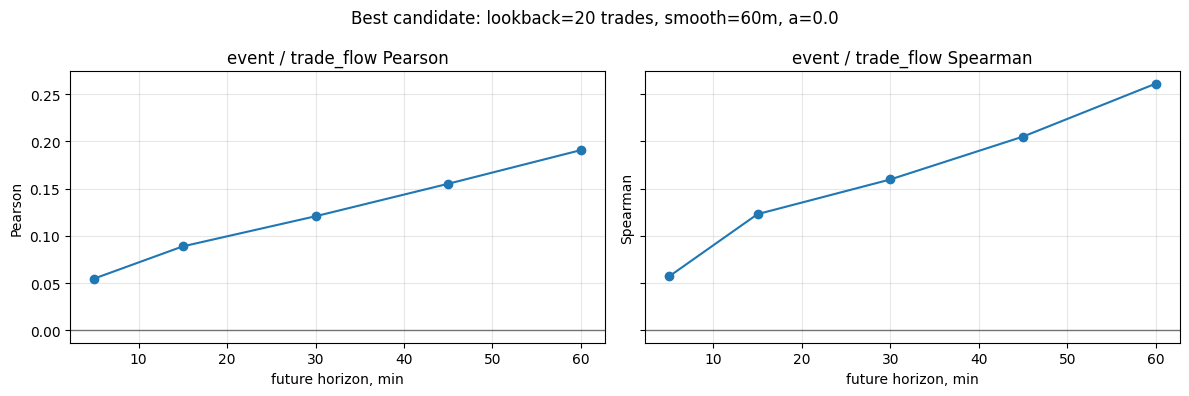

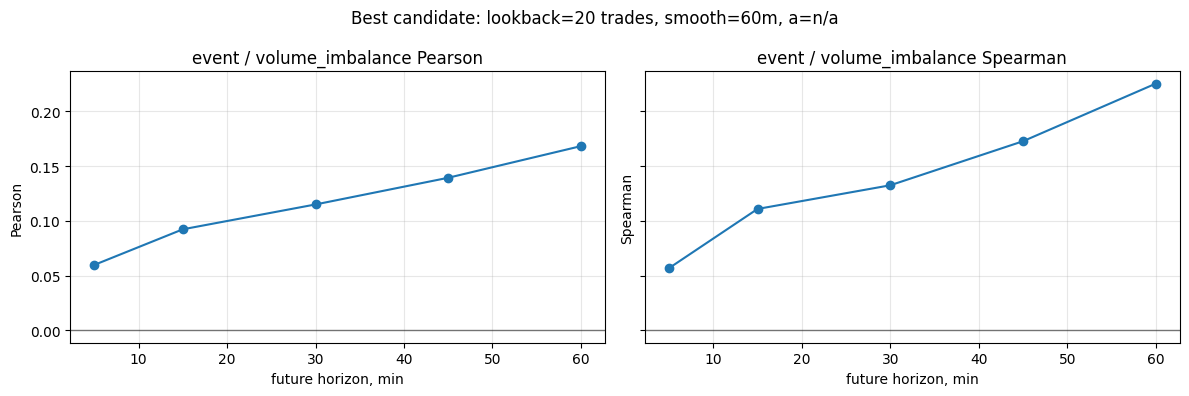

In [9]:
event_return_frame = build_future_return_frame(clock_grid, RETURN_HORIZON_MIN_LIST)

event_signal_frames = []
for signal_T in EVENT_LOOKBACK_T_LIST:
    for a in A_LIST:
        base = build_event_signal_frame(trade_frame, signal_T=signal_T, a=a)
        for smooth_min in SMOOTH_WINDOW_MIN_LIST:
            smoothed = smooth_signal_frame(base, window_min=smooth_min)
            event_signal_frames.append({
                "signal_mode": "event",
                "signal_family": "trade_flow",
                "lookback_label": f"{signal_T} trades",
                "lookback_value": signal_T,
                "smooth_min": smooth_min,
                "a": a,
                "frame": smoothed,
                "signal_cols": ["trade_flow_raw"],
            })

for signal_T in EVENT_LOOKBACK_T_LIST:
    base = build_event_signal_frame(trade_frame, signal_T=signal_T, a=0.0)
    for smooth_min in SMOOTH_WINDOW_MIN_LIST:
        smoothed = smooth_signal_frame(base[["ts", "volume_imbalance"]], window_min=smooth_min)
        event_signal_frames.append({
            "signal_mode": "event",
            "signal_family": "volume_imbalance",
            "lookback_label": f"{signal_T} trades",
            "lookback_value": signal_T,
            "smooth_min": smooth_min,
            "a": np.nan,
            "frame": smoothed,
            "signal_cols": ["volume_imbalance"],
        })

for signal_T in EVENT_LOOKBACK_T_LIST:
    for a in A_LIST:
        base = build_event_signal_frame(trade_frame, signal_T=signal_T, a=a)
        tail = filter_high_imbalance_frame(base[["ts", "trade_flow_raw"]], "trade_flow_raw", HIGH_IMBALANCE_Q, out_col="trade_flow_high_imbalance")
        for smooth_min in SMOOTH_WINDOW_MIN_LIST:
            smoothed = smooth_signal_frame(tail, window_min=smooth_min)
            event_signal_frames.append({
                "signal_mode": "event",
                "signal_family": "trade_flow_high_imbalance_q90",
                "lookback_label": f"{signal_T} trades",
                "lookback_value": signal_T,
                "smooth_min": smooth_min,
                "a": a,
                "frame": smoothed,
                "signal_cols": ["trade_flow_high_imbalance"],
            })

for signal_T in EVENT_LOOKBACK_T_LIST:
    base = build_event_signal_frame(trade_frame, signal_T=signal_T, a=0.0)
    tail = filter_high_imbalance_frame(base[["ts", "volume_imbalance"]], "volume_imbalance", HIGH_IMBALANCE_Q, out_col="volume_imbalance_high_imbalance")
    for smooth_min in SMOOTH_WINDOW_MIN_LIST:
        smoothed = smooth_signal_frame(tail, window_min=smooth_min)
        event_signal_frames.append({
            "signal_mode": "event",
            "signal_family": "volume_imbalance_high_imbalance_q90",
            "lookback_label": f"{signal_T} trades",
            "lookback_value": signal_T,
            "smooth_min": smooth_min,
            "a": np.nan,
            "frame": smoothed,
            "signal_cols": ["volume_imbalance_high_imbalance"],
        })

event_scan_df = scan_signal_frames(event_signal_frames, event_return_frame, RETURN_HORIZON_MIN_LIST)
display(event_scan_df.head(20))
display(summarize_candidates(event_scan_df).sort_values(["best_abs_pearson", "mean_abs_pearson"], ascending=False).head(20))

plot_candidate_curves(event_scan_df, signal_mode="event", signal_family="trade_flow")
plot_candidate_curves(event_scan_df, signal_mode="event", signal_family="volume_imbalance")

## Clock-Time Signals

These signals are defined on a 1-second grid using wall-clock lookback windows.

The lookback, smoothing, and return horizons are all in minutes.

,signal_mode,signal_family,lookback_label,lookback_value,smooth_min,a,signal_col,horizon_min,pearson,spearman,n
0,clock,trade_flow,5 min,5,5,0.0,trade_flow_raw,5,0.080570,0.061521,79792
1,clock,trade_flow,5 min,5,5,0.0,trade_flow_raw,15,0.059786,0.076518,79192
2,clock,trade_flow,5 min,5,5,0.0,trade_flow_raw,30,0.084829,0.110374,78292
3,clock,trade_flow,5 min,5,5,0.0,trade_flow_raw,45,0.106284,0.129165,77392
4,clock,trade_flow,5 min,5,5,0.0,trade_flow_raw,60,0.095754,0.179980,76492
5,clock,trade_flow,5 min,5,15,0.0,trade_flow_raw,5,0.064888,0.061914,79792
6,clock,trade_flow,5 min,5,15,0.0,trade_flow_raw,15,0.085195,0.117097,79192
7,clock,trade_flow,5 min,5,15,0.0,trade_flow_raw,30,0.109684,0.153392,78292
8,clock,trade_flow,5 min,5,15,0.0,trade_flow_raw,45,0.116376,0.172196,77392
9,clock,trade_flow,5 min,5,15,0.0,trade_flow_raw,60,0.120662,0.222674,76492


,signal_mode,signal_family,lookback_label,smooth_min,a,mean_abs_pearson,mean_abs_spearman,best_abs_pearson,best_abs_spearman,best_horizon_min
179,clock,trade_flow_high_imbalance_q90,5 min,60,1.0,0.282636,0.107749,0.307867,0.136593,15
175,clock,trade_flow_high_imbalance_q90,5 min,45,1.0,0.245338,0.103542,0.266619,0.131620,60
79,clock,trade_flow,5 min,60,1.0,0.238310,0.120962,0.263463,0.162079,45
171,clock,trade_flow_high_imbalance_q90,5 min,30,1.0,0.227153,0.063601,0.258894,0.088106,15
75,clock,trade_flow,5 min,45,1.0,0.213825,0.105380,0.243305,0.173494,60
244,clock,volume_imbalance_high_imbalance_q90,5 min,60,NaN,0.181399,0.294891,0.233510,0.420030,60
185,clock,trade_flow_high_imbalance_q90,60 min,15,0.3,0.163702,0.119275,0.229856,0.173643,60
181,clock,trade_flow_high_imbalance_q90,60 min,5,0.3,0.156080,0.149114,0.228491,0.196367,60
224,clock,volume_imbalance,60 min,60,NaN,0.173015,0.161033,0.227712,0.251550,60
243,clock,volume_imbalance_high_imbalance_q90,5 min,45,NaN,0.167567,0.290293,0.221698,0.429014,60


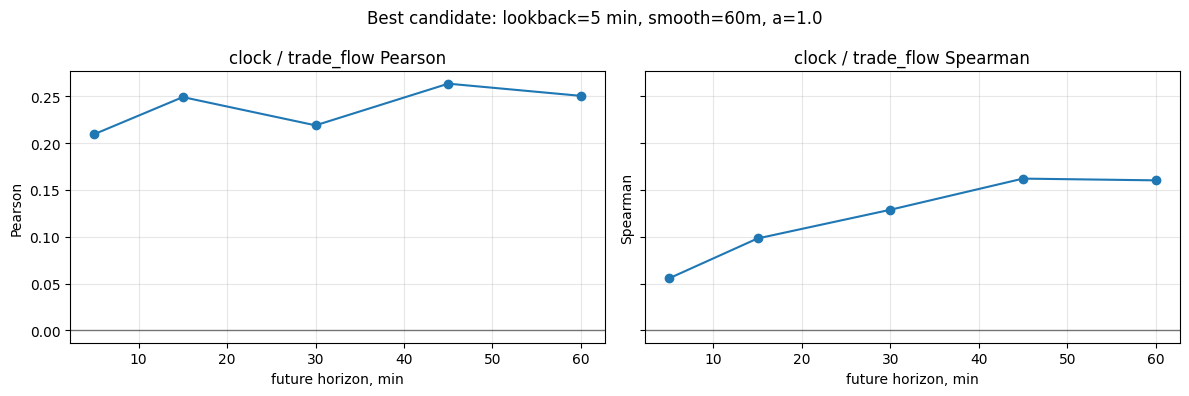

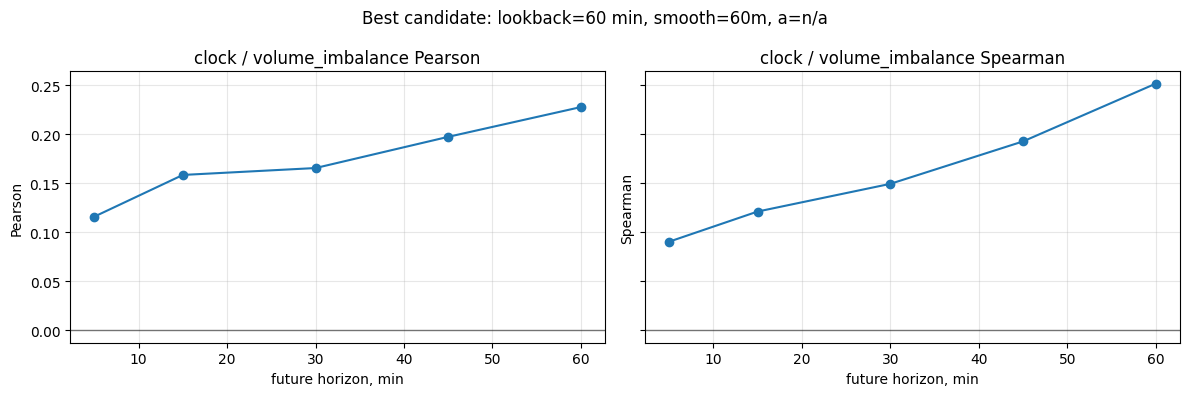

In [10]:
clock_signal_frames = []
for lookback_min in CLOCK_LOOKBACK_MIN_LIST:
    for a in A_LIST:
        base = build_clock_signal_frame(trade_frame, clock_grid, lookback_min=lookback_min, a=a)
        for smooth_min in SMOOTH_WINDOW_MIN_LIST:
            smoothed = smooth_signal_frame(base, window_min=smooth_min)
            clock_signal_frames.append({
                "signal_mode": "clock",
                "signal_family": "trade_flow",
                "lookback_label": f"{lookback_min} min",
                "lookback_value": lookback_min,
                "smooth_min": smooth_min,
                "a": a,
                "frame": smoothed,
                "signal_cols": ["trade_flow_raw"],
            })

for lookback_min in CLOCK_LOOKBACK_MIN_LIST:
    base = build_clock_signal_frame(trade_frame, clock_grid, lookback_min=lookback_min, a=0.0)
    for smooth_min in SMOOTH_WINDOW_MIN_LIST:
        smoothed = smooth_signal_frame(base[["ts", "volume_imbalance"]], window_min=smooth_min)
        clock_signal_frames.append({
            "signal_mode": "clock",
            "signal_family": "volume_imbalance",
            "lookback_label": f"{lookback_min} min",
            "lookback_value": lookback_min,
            "smooth_min": smooth_min,
            "a": np.nan,
            "frame": smoothed,
            "signal_cols": ["volume_imbalance"],
        })

for lookback_min in CLOCK_LOOKBACK_MIN_LIST:
    for a in A_LIST:
        base = build_clock_signal_frame(trade_frame, clock_grid, lookback_min=lookback_min, a=a)
        tail = filter_high_imbalance_frame(base[["ts", "trade_flow_raw"]], "trade_flow_raw", HIGH_IMBALANCE_Q, out_col="trade_flow_high_imbalance")
        for smooth_min in SMOOTH_WINDOW_MIN_LIST:
            smoothed = smooth_signal_frame(tail, window_min=smooth_min)
            clock_signal_frames.append({
                "signal_mode": "clock",
                "signal_family": "trade_flow_high_imbalance_q90",
                "lookback_label": f"{lookback_min} min",
                "lookback_value": lookback_min,
                "smooth_min": smooth_min,
                "a": a,
                "frame": smoothed,
                "signal_cols": ["trade_flow_high_imbalance"],
            })

for lookback_min in CLOCK_LOOKBACK_MIN_LIST:
    base = build_clock_signal_frame(trade_frame, clock_grid, lookback_min=lookback_min, a=0.0)
    tail = filter_high_imbalance_frame(base[["ts", "volume_imbalance"]], "volume_imbalance", HIGH_IMBALANCE_Q, out_col="volume_imbalance_high_imbalance")
    for smooth_min in SMOOTH_WINDOW_MIN_LIST:
        smoothed = smooth_signal_frame(tail, window_min=smooth_min)
        clock_signal_frames.append({
            "signal_mode": "clock",
            "signal_family": "volume_imbalance_high_imbalance_q90",
            "lookback_label": f"{lookback_min} min",
            "lookback_value": lookback_min,
            "smooth_min": smooth_min,
            "a": np.nan,
            "frame": smoothed,
            "signal_cols": ["volume_imbalance_high_imbalance"],
        })

clock_scan_df = scan_signal_frames(clock_signal_frames, event_return_frame, RETURN_HORIZON_MIN_LIST)
display(clock_scan_df.head(40))
display(summarize_candidates(clock_scan_df).sort_values(["best_abs_pearson", "mean_abs_pearson"], ascending=False).head(40))

plot_candidate_curves(clock_scan_df, signal_mode="clock", signal_family="trade_flow")
plot_candidate_curves(clock_scan_df, signal_mode="clock", signal_family="volume_imbalance")

In [20]:
display(clock_scan_df.loc[(clock_scan_df["pearson"]>0.3)])


,signal_mode,signal_family,lookback_label,lookback_value,smooth_min,a,signal_col,horizon_min,pearson,spearman,n
721,clock,trade_flow_high_imbalance_q90,5 min,5,60,1.0,trade_flow_high_imbalance,15,0.307867,0.11335,79192
723,clock,trade_flow_high_imbalance_q90,5 min,5,60,1.0,trade_flow_high_imbalance,45,0.301134,0.12805,77392


## Reading The Results

The useful questions here are not whether one single parameter is best.

The question is whether the same family stays reasonably strong across neighboring lookbacks, smoothing windows, and return horizons.

A good mid-term candidate should be stable across days and should not depend on one narrow window choice.